# Análise Exploratória de Dados: Previsão de Ativos (DIS)
**Objetivo:** Analisar o comportamento histórico das ações da Disney (DIS) para fundamentar a construção do modelo LSTM.

Imports

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1 - Extração dos dados

In [5]:
symbol = 'DIS'
start_date = '2023-01-01'
end_date = pd.Timestamp.now().strftime('%Y-%m-%d')

In [6]:
df = yf.download(symbol, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [7]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,DIS,DIS,DIS,DIS,DIS
Date,,,,,
2023-01-03,86.923012,87.900004,85.809241,86.932784,14997100
2023-01-04,89.863770,90.616050,87.304047,87.929321,14957200
2023-01-05,89.805145,90.352266,88.427590,89.551133,11622600
2023-01-06,91.759117,92.511405,89.218939,90.528112,9828100
2023-01-09,92.589569,93.498172,91.299939,92.257395,11675800


In [9]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,DIS,DIS,DIS,DIS,DIS
count,815.000000,815.000000,815.000000,815.000000,8.150000e+02
mean,100.290087,101.248201,99.278592,100.214821,1.118185e+07
std,11.498578,11.550323,11.408960,11.447866,6.140227e+06
min,77.495041,77.954229,76.918619,77.280104,2.475000e+06
25%,90.386707,91.114316,89.348795,90.251181,7.774350e+06
50%,99.507523,100.507297,98.693971,99.360122,9.723600e+06
75%,110.700474,111.816611,109.652341,110.536133,1.260635e+07
max,123.176605,123.852036,122.352181,123.474585,6.055840e+07


### 2 - Análise de tendência no mercado e médias móveis

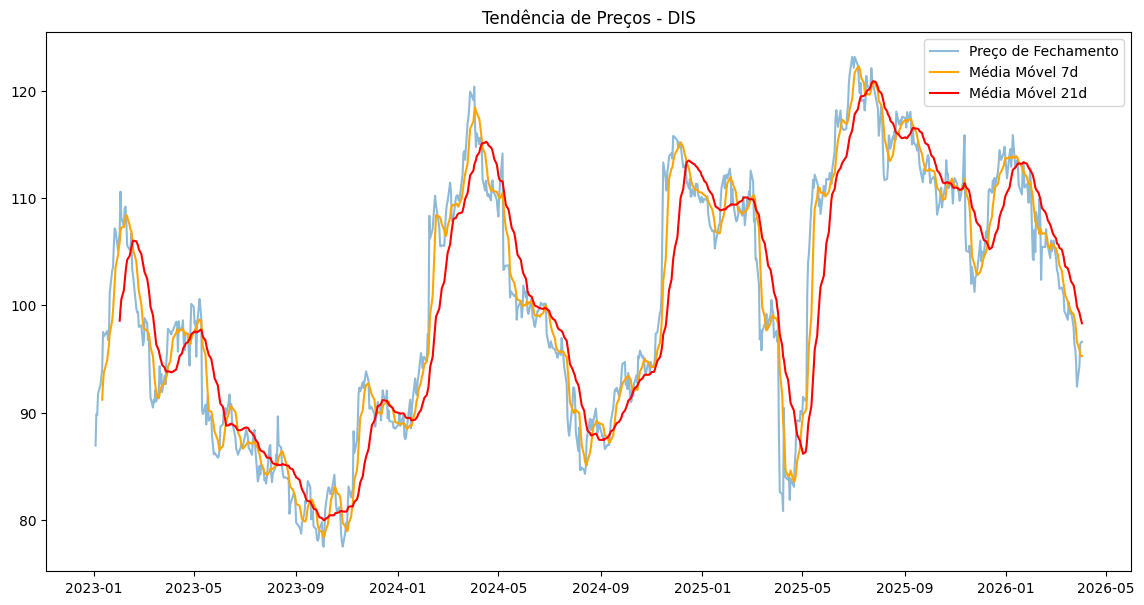

In [10]:
plt.figure(figsize=(14, 7))
plt.plot(df['Close'], label='Preço de Fechamento', alpha=0.5)
plt.plot(df['Close'].rolling(window=7).mean(), label='Média Móvel 7d', color='orange')
plt.plot(df['Close'].rolling(window=21).mean(), label='Média Móvel 21d', color='red')
plt.title(f'Tendência de Preços - {symbol}')
plt.legend()
plt.show()

### 3 - Análise de Volatilidade e Retornos

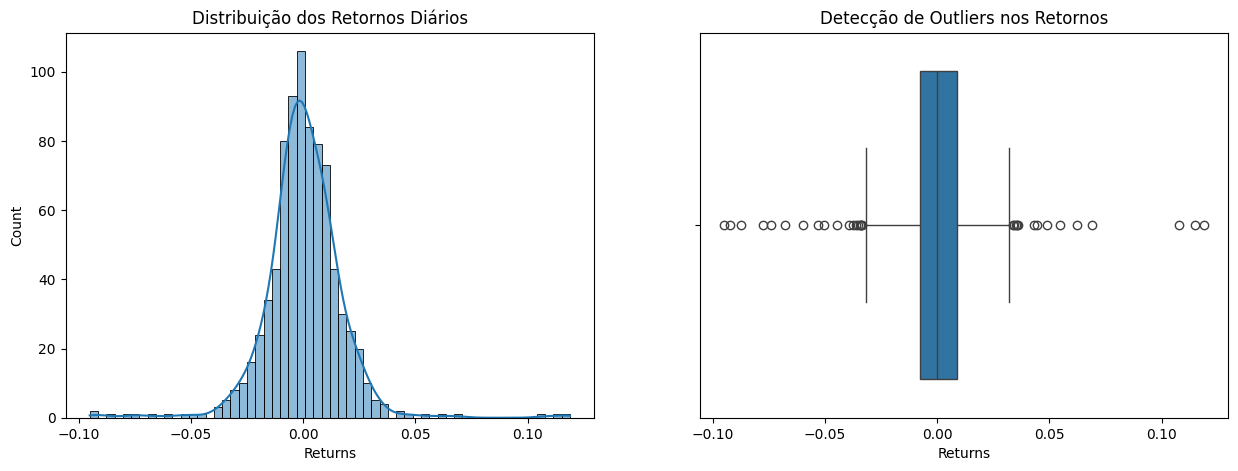

In [11]:
df['Returns'] = df['Close'].pct_change().dropna()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['Returns'].dropna(), kde=True, ax=ax[0])
ax[0].set_title('Distribuição dos Retornos Diários')

sns.boxplot(x=df['Returns'], ax=ax[1])
ax[1].set_title('Detecção de Outliers nos Retornos')
plt.show()

### 4 - Relação Preço vs Volume

TypeError: only 0-dimensional arrays can be converted to Python scalars

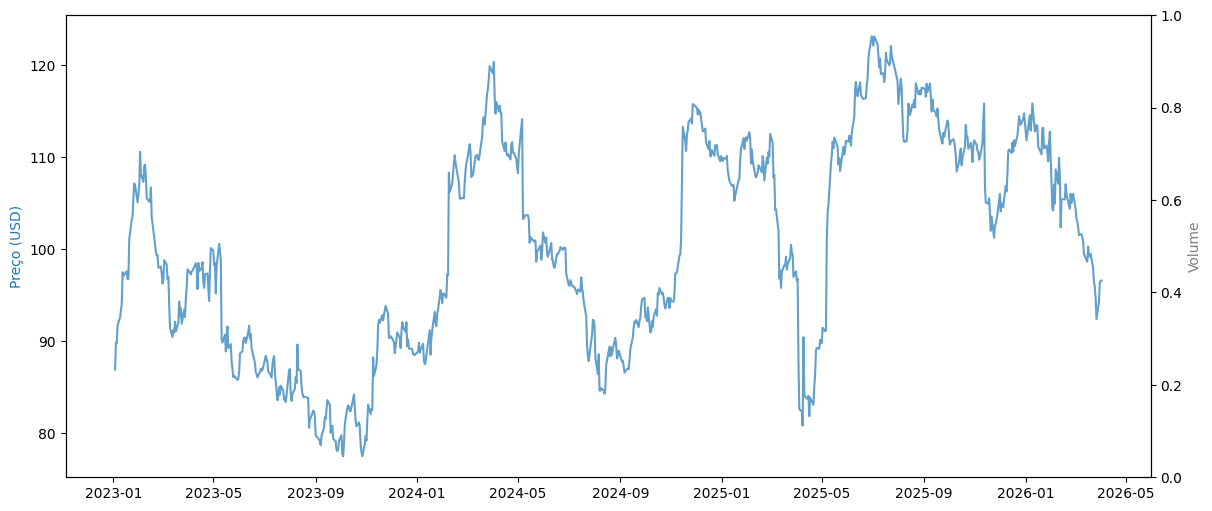

In [12]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.set_ylabel('Preço (USD)', color='tab:blue')
ax1.plot(df.index, df['Close'], color='tab:blue', alpha=0.7)

ax2 = ax1.twinx()
ax2.set_ylabel('Volume', color='tab:gray')
ax2.bar(df.index, df['Volume'], color='tab:gray', alpha=0.3)

plt.title('Preço de Fechamento vs Volume de Transações')
plt.show()

### 5 - Mapa de Correlação

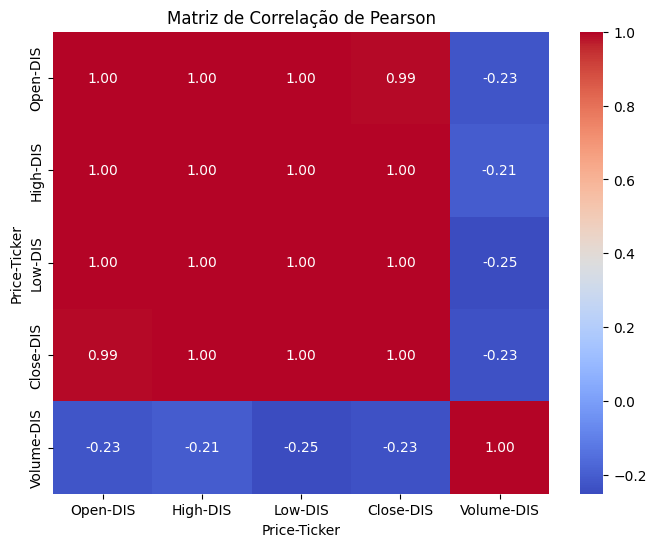

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Open', 'High', 'Low', 'Close', 'Volume']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação de Pearson')
plt.show()